In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt



#mnist dataset
train_dataset = datasets.MNIST(root='./data', train=True, transform=transforms.ToTensor(), download=True)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()

        #encoder
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)
        
        #decoder
        self.fc2 = nn.Linear(latent_dim, 400)
        self.fc3 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decode(z)
        return reconstructed, mu, logvar

def vae_loss(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [3]:
def train_vae(latent_dim=2, epochs=30):
    print(f"\nTraining VAE with latent dimension = {latent_dim}")
    model = VAE(latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for images, _ in train_loader:
            images = images.to(device)
            recon, mu, logvar = model(images)
            loss = vae_loss(recon, images, mu, logvar)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")
    
    return model

In [4]:
vae_2d = train_vae(latent_dim=2)


Training VAE with latent dimension = 2
Epoch [1/30], Loss: 190.5177
Epoch [2/30], Loss: 167.5889
Epoch [3/30], Loss: 163.0188
Epoch [4/30], Loss: 160.5611
Epoch [5/30], Loss: 158.9798
Epoch [6/30], Loss: 157.7816
Epoch [7/30], Loss: 156.7506
Epoch [8/30], Loss: 155.8643
Epoch [9/30], Loss: 155.1127
Epoch [10/30], Loss: 154.4240
Epoch [11/30], Loss: 153.8846
Epoch [12/30], Loss: 153.2892
Epoch [13/30], Loss: 152.8263
Epoch [14/30], Loss: 152.3360
Epoch [15/30], Loss: 151.9711
Epoch [16/30], Loss: 151.5725
Epoch [17/30], Loss: 151.2453
Epoch [18/30], Loss: 150.9013
Epoch [19/30], Loss: 150.6246
Epoch [20/30], Loss: 150.3044
Epoch [21/30], Loss: 150.0246
Epoch [22/30], Loss: 149.7529
Epoch [23/30], Loss: 149.5450
Epoch [24/30], Loss: 149.2731
Epoch [25/30], Loss: 149.0958
Epoch [26/30], Loss: 148.8907
Epoch [27/30], Loss: 148.6531
Epoch [28/30], Loss: 148.4573
Epoch [29/30], Loss: 148.2738
Epoch [30/30], Loss: 148.0995


In [5]:
def sample_and_visualize(model, latent_dim, num_samples=10):
    model.eval()
    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim).to(device)
        out = model.decode(z).cpu()
        fig, axes = plt.subplots(1, num_samples, figsize=(num_samples*2, 2))
        for i in range(num_samples):
            axes[i].imshow(out[i].view(28, 28), cmap='gray')
            axes[i].axis('off')
        plt.show()

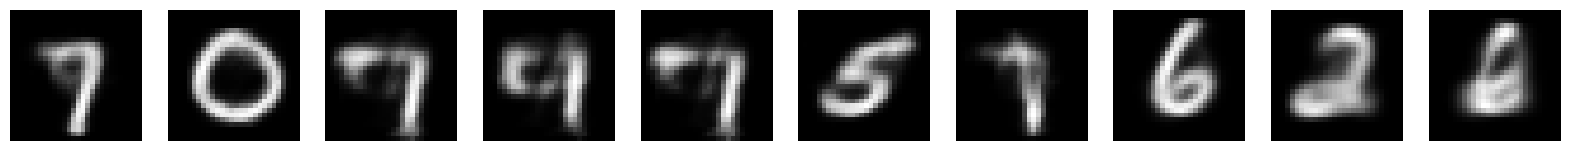

In [6]:
sample_and_visualize(vae_2d, 2)

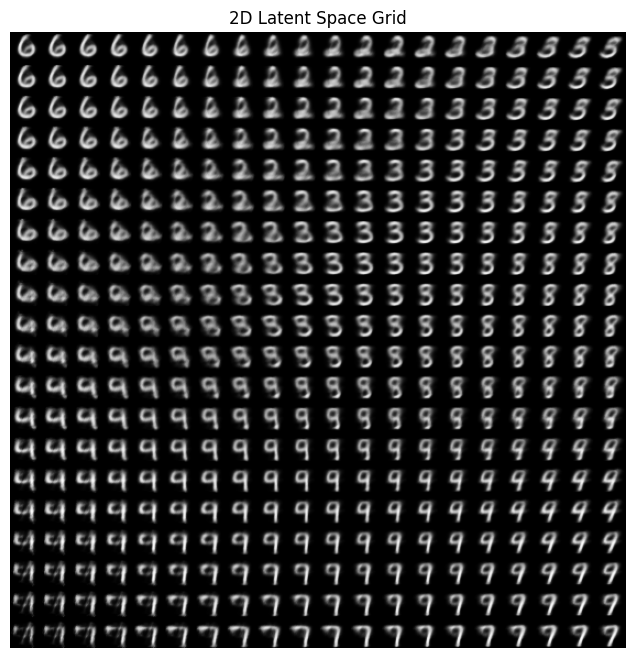

In [8]:
def visualize_latent_grid(model, grid_size=20, range_val=2.0):
    model.eval()
    with torch.no_grad():
        figure = torch.zeros((28 * grid_size, 28 * grid_size))
        linspace = torch.linspace(-range_val, range_val, grid_size)

        for i, yi in enumerate(linspace):
            for j, xi in enumerate(linspace):
                z = torch.tensor([[xi, yi]]).to(device)
                x_hat = model.decode(z)
                digit = x_hat.view(28, 28).cpu()
                figure[i * 28: (i + 1) * 28, j * 28: (j + 1) * 28] = digit

        plt.figure(figsize=(8, 8))
        plt.imshow(figure.numpy(), cmap='gray')
        plt.axis('off')
        plt.title("2D Latent Space Grid")
        plt.show()

visualize_latent_grid(vae_2d, grid_size=20, range_val=1.0)

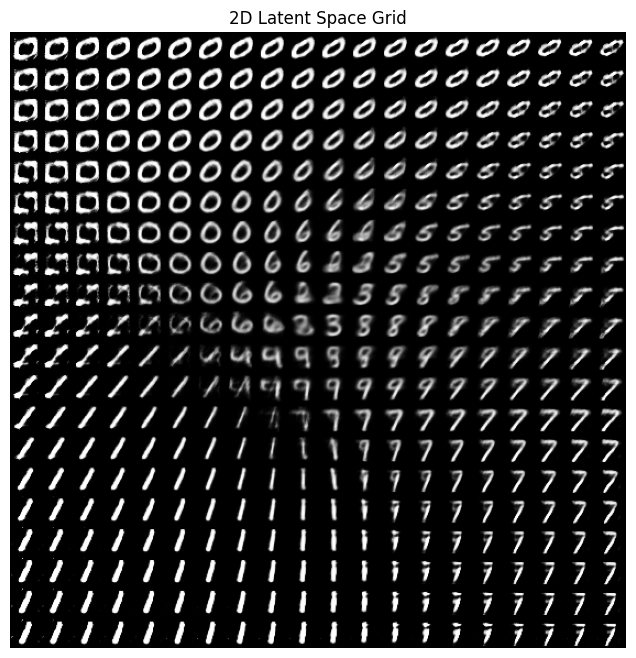

In [9]:
visualize_latent_grid(vae_2d, grid_size=20, range_val=5.0)